<a href="https://colab.research.google.com/github/ciberguard/JobSearch/blob/main/animal_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: stevendwisilalahi
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:11<00:00, 63.1MB/s]


In [ ]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cuda


In [ ]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].unique())
data_df.head()

['cat' 'dog' 'wild']


,image_path,labels
0,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
1,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
2,/content/animal-faces/afhq/train/cat/flickr_ca...,cat
3,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
4,/content/animal-faces/afhq/train/cat/pixabay_c...,cat


In [ ]:
train = data_df.sample(frac = 0.7)
test = data_df.drop(train.index)

val = test.sample(frac = 0.5)
test = test.drop(val.index)

print(train.shape, test.shape, val.shape)

(11291, 2) (2419, 2) (2420, 2)


In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

# transform baru
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

val_test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [ ]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label

In [ ]:
# pemanggilan variabel transform baru
train_dataset = CustomImageDataset(dataframe = train, transform = train_transform)
test_dataset = CustomImageDataset(dataframe = test, transform = val_test_transform)
val_dataset = CustomImageDataset(dataframe = val, transform = val_test_transform)

In [ ]:
print(train.iloc[2, 0])

/content/animal-faces/afhq/val/dog/pixabay_dog_000484.jpg


In [ ]:
train_dataset.__getitem__(2)

(tensor([[[0.8627, 0.8706, 0.8784,  ..., 0.9020, 0.8941, 0.8902],
          [0.8627, 0.8706, 0.8745,  ..., 0.9020, 0.9020, 0.8902],
          [0.8627, 0.8706, 0.8667,  ..., 0.9020, 0.8980, 0.8902],
          ...,
          [0.6196, 0.6314, 0.6510,  ..., 0.6627, 0.6745, 0.6824],
          [0.6078, 0.6235, 0.6392,  ..., 0.6471, 0.6549, 0.6667],
          [0.6039, 0.6235, 0.6275,  ..., 0.6314, 0.6392, 0.6510]],
 
         [[0.9020, 0.9098, 0.9176,  ..., 0.9294, 0.9216, 0.9176],
          [0.9020, 0.9098, 0.9137,  ..., 0.9294, 0.9294, 0.9176],
          [0.9020, 0.9098, 0.9059,  ..., 0.9294, 0.9255, 0.9176],
          ...,
          [0.4941, 0.5059, 0.5255,  ..., 0.7176, 0.7333, 0.7490],
          [0.4863, 0.5059, 0.5216,  ..., 0.7059, 0.7216, 0.7333],
          [0.4863, 0.5059, 0.5137,  ..., 0.6902, 0.7059, 0.7176]],
 
         [[0.9412, 0.9490, 0.9569,  ..., 0.9608, 0.9529, 0.9490],
          [0.9412, 0.9490, 0.9529,  ..., 0.9608, 0.9608, 0.9490],
          [0.9412, 0.9490, 0.9451,  ...,

In [ ]:
label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

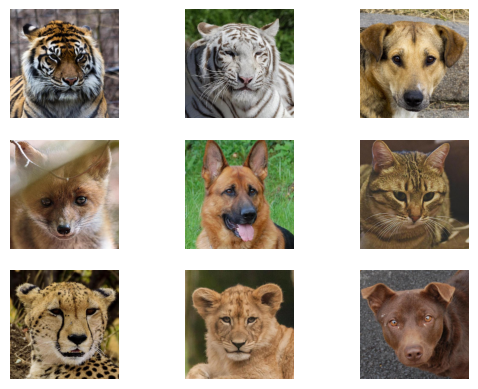

In [ ]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

In [ ]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding= 1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding= 1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding= 1)

    self.pooling = nn.MaxPool2d(2, 2)

    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.dropout = nn.Dropout(p=0.4) #tambah dropout
    self.linear = nn.Linear((128*16*16), 128)

    self.output = nn.Linear(128, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv3(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.flatten(x)
    x = self.dropout(x) #tambah dropout
    x = self.linear(x)
    x = self.relu(x) #tambah rule
    x = self.dropout(x) #ditambah dropout
    x = self.output(x)

    return x

In [ ]:
model = Net().to(device)

In [ ]:
from torchsummary import summary
summary(model, input_size = (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR, weight_decay=1e-4) #tambahin weight_decay

In [ ]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  model.train() #tambah model train
  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()

    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    model.eval() #tambah model.eval
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis= 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round((total_acc_train/train_dataset.__len__()) * 100, 4))
  total_acc_validation_plot.append(round((total_acc_val/val_dataset.__len__()) * 100, 4))

  print(f'''Epoch {epoch +1}/{EPOCHS},
            Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy {round((total_acc_train/train_dataset.__len__()) * 100, 4)}
            Validation Loss {round(total_loss_val/1000, 4)} Validation Accuracy {round((total_acc_val/val_dataset.__len__()) * 100, 4)}
        ''')

Epoch 1/10, 
            Train Loss: 0.3288 Train Accuracy 80.3295
            Validation Loss 0.0349 Validation Accuracy 92.3554
        
Epoch 2/10, 
            Train Loss: 0.1333 Train Accuracy 93.2778
            Validation Loss 0.0256 Validation Accuracy 93.3471
        
Epoch 3/10, 
            Train Loss: 0.0855 Train Accuracy 95.678
            Validation Loss 0.0253 Validation Accuracy 94.5868
        
Epoch 4/10, 
            Train Loss: 0.0618 Train Accuracy 96.9888
            Validation Loss 0.0182 Validation Accuracy 96.0744
        
Epoch 5/10, 
            Train Loss: 0.0481 Train Accuracy 97.6176
            Validation Loss 0.0164 Validation Accuracy 96.4463
        
Epoch 6/10, 
            Train Loss: 0.0351 Train Accuracy 98.3527
            Validation Loss 0.0201 Validation Accuracy 95.7025
        
Epoch 7/10, 
            Train Loss: 0.0259 Train Accuracy 98.7512
            Validation Loss 0.0183 Validation Accuracy 96.6529
        
Epoch 8/10, 
            Tra

In [ ]:
model.eval() #tambah model.eval
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")


Accuracy Score is: 95.7007 and Loss is 0.0231


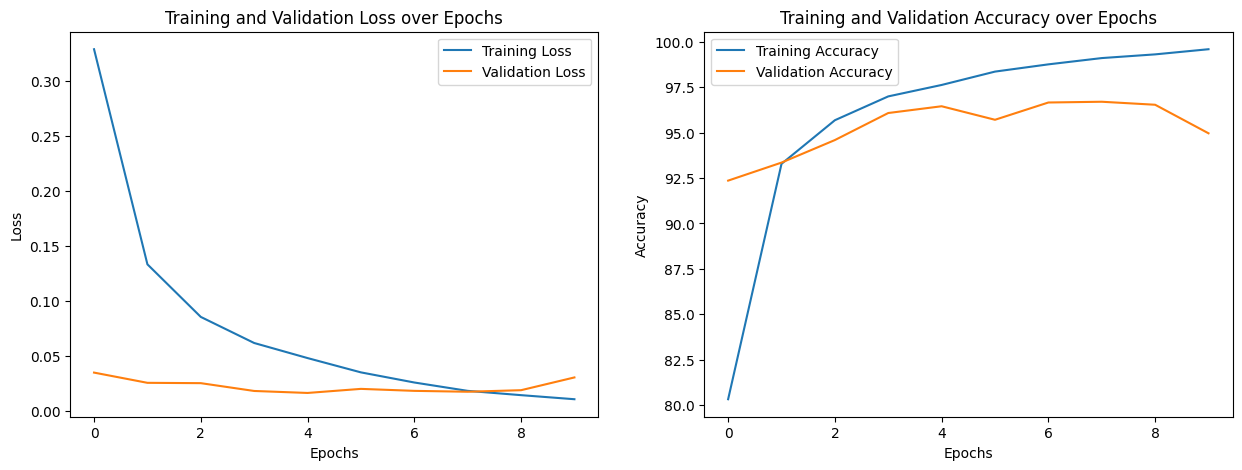

In [ ]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [ ]:
def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')  #ganti jadi image_path
  image = val_test_transform(image).to(device) #jadi val_test_transform
  model.eval() #tambah model.eval
  with torch.no_grad(): #tambah with torch.no_grad
  output = model(image.unsqueeze(0))

  output = torch.argmax(output, axis= 1).item()
  return label_encoder.inverse_transform([output])

In [ ]:
predict_image("/content/cat.jpg")

array(['wild'], dtype=object)